
# Validating Against Romano et al. (2020) Using Real NANOGrav Pulsar Positions

**Purpose.** Section III of Romano, Hazboun, Siemens & Archibald (2020, arXiv:2012.03804)
derives closed-form SNR expressions for the common-spectrum (CP) and Hellings-Downs (HD)
estimators, and reports specific numbers for the real N=45 NANOGrav pulsar array:

| | weak-signal coefficient | intermediate-signal (plateau) |
|---|---|---|
| $\rho_{\rm CP}^2$ | $N/2 = 22.5$ | $\approx 20.0$ |
| $\rho_{\rm HD}^2$ | $\approx 66$ | $\approx 4.66$ |
| $\rho_{\rm CP}/\rho_{\rm HD}$ | $\approx 0.6$ | $\approx 2.1$ |

This notebook reproduces those numbers **independently** — using real NANOGrav pulsar sky
positions (not a synthetic star field) and a from-scratch implementation of Romano's own
covariance formulas (Eq. 29 for CP, Eq. 35-37 for HD) — rather than reusing this project's
astrometric-deflection code, since PTA timing residuals and astrometric star deflections
are different physical setups that happen to share the same angular kernel shape.

**Data source.** The 45 real pulsar sky positions are taken from Arzoumanian et al. (2018,
arXiv:1801.01837), Table 4 — the NANOGrav 11-year data set's equatorial coordinates for
its 45-pulsar GWB array. This is the same 45-pulsar set (up to the ~1.5 additional years
and 2 new not-yet-3-year-baseline pulsars added in the 12.5-year release) that Romano's
Figure 3 is computed from.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Real NANOGrav 11-yr 45-pulsar equatorial coordinates (Arzoumanian et al. 2018, Table 4)
PULSARS_HMS_DMS = [
    ("J0023+0923",  "00:23:16.87821",  "+09:23:23.8646"),
    ("J0030+0451",  "00:30:27.42785",  "+04:51:39.711"),
    ("J0340+4130",  "03:40:23.28816",  "+41:30:45.2862"),
    ("J0613-0200",  "06:13:43.975825", "-02:00:47.2372"),
    ("J0636+5128",  "06:36:04.847128", "+51:28:59.9609"),
    ("J0645+5158",  "06:45:59.082079", "+51:58:14.91290"),
    ("J0740+6620",  "07:40:45.79492",  "+66:20:33.5593"),
    ("J0931-1902",  "09:31:19.11739",  "-19:02:55.0282"),
    ("J1012+5307",  "10:12:33.43776",  "+53:07:02.2801"),
    ("J1024-0719",  "10:24:38.667358", "-07:19:19.5974"),
    ("J1125+7819",  "11:25:59.8485",   "+78:19:48.7161"),
    ("J1453+1902",  "14:53:45.71922",  "+19:02:12.1270"),
    ("J1455-3330",  "14:55:47.97035",  "-33:30:46.3818"),
    ("J1600-3053",  "16:00:51.903178", "-30:53:49.3919"),
    ("J1614-2230",  "16:14:36.50741",  "-22:30:31.265"),
    ("J1640+2224",  "16:40:16.745013", "+22:24:08.82970"),
    ("J1643-1224",  "16:43:38.16189",  "-12:24:58.671"),
    ("J1713+0747",  "17:13:49.5335505","+07:47:37.48838"),
    ("J1738+0333",  "17:38:53.968032", "+03:33:10.8893"),
    ("J1741+1351",  "17:41:31.144731", "+13:51:44.12188"),
    ("J1744-1134",  "17:44:29.408577", "-11:34:54.7022"),
    ("J1747-4036",  "17:47:48.71652",  "-40:36:54.784"),
    ("J1832-0836",  "18:32:27.592888", "-08:36:55.0115"),
    ("J1853+1303",  "18:53:57.318327", "+13:03:44.05670"),
    ("B1855+09",    "18:57:36.390442", "+09:43:17.20167"),
    ("J1903+0327",  "19:03:05.79256",  "+03:27:19.1851"),
    ("J1909-3744",  "19:09:47.432840", "-37:44:14.54898"),
    ("J1910+1256",  "19:10:09.701512", "+12:56:25.4648"),
    ("J1911+1347",  "19:11:55.203652", "+13:47:34.36424"),
    ("J1918-0642",  "19:18:48.032707", "-06:42:34.8948"),
    ("J1923+2515",  "19:23:22.492681", "+25:15:40.59748"),
    ("B1937+21",    "19:39:38.561253", "+21:34:59.12518"),
    ("J1944+0907",  "19:44:09.330945", "+09:07:23.0118"),
    ("B1953+29",    "19:55:27.875424", "+29:08:43.4415"),
    ("J2010-1323",  "20:10:45.921236", "-13:23:56.0854"),
    ("J2017+0603",  "20:17:22.705247", "+06:03:05.5689"),
    ("J2033+1734",  "20:33:27.51189",  "+17:34:58.4747"),
    ("J2043+1711",  "20:43:20.881730", "+17:11:28.91265"),
    ("J2145-0750",  "21:45:50.46014",  "-07:50:18.499"),
    ("J2214+3000",  "22:14:38.85274",  "+30:00:38.1953"),
    ("J2229+2643",  "22:29:50.88471",  "+26:43:57.6507"),
    ("J2234+0611",  "22:34:23.074172", "+06:11:28.6922"),
    ("J2234+0944",  "22:34:46.85388",  "+09:44:30.2487"),
    ("J2302+4442",  "23:02:46.97874",  "+44:42:22.0860"),
    ("J2317+1439",  "23:17:09.236663", "+14:39:31.2556"),
]

def hms_to_deg(hms):
    h, m, s = hms.split(":")
    return (float(h) + float(m)/60 + float(s)/3600) * 15.0

def dms_to_deg(dms):
    sign = -1.0 if dms.strip().startswith("-") else 1.0
    dms = dms.strip().lstrip("+-")
    d, m, s = dms.split(":")
    return sign * (float(d) + float(m)/60 + float(s)/3600)

names = [p[0] for p in PULSARS_HMS_DMS]
ra_deg = np.array([hms_to_deg(p[1]) for p in PULSARS_HMS_DMS])
dec_deg = np.array([dms_to_deg(p[2]) for p in PULSARS_HMS_DMS])
N = len(names)
print(f"Loaded N={N} real pulsars (expect 45).")


Loaded N=45 real pulsars (expect 45).



## Angular separations and the classic Hellings-Downs correlation

Unlike the astrometric-deflection kernel elsewhere in this project (a multipole sum over
$\ell$, specific to star-field deflections), PTA analyses use the **classic, closed-form**
Hellings & Downs (1983) function directly:
$$
\chi(\zeta) = \frac{1}{2} - \frac{1}{4}\left(\frac{1-\cos\zeta}{2}\right) + \frac{3}{2}\left(\frac{1-\cos\zeta}{2}\right)\ln\left(\frac{1-\cos\zeta}{2}\right)
$$
with $\chi(0)=\tfrac12$ by continuity (the $x\ln x\to0$ limit).


Real pairwise separations range: 0.95 deg to 177.33 deg
(Compare: this project's astrometric FoV sweeps top out at 160 deg by construction --
 real pulsars span the genuinely full sky, out to nearly antipodal.)


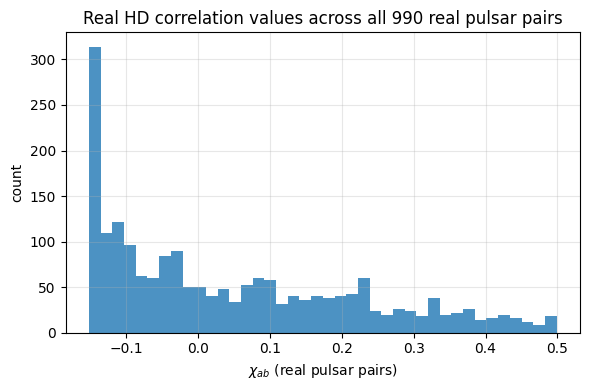

In [2]:

ra = np.deg2rad(ra_deg); dec = np.deg2rad(dec_deg)
dra = ra[:, None] - ra[None, :]
ddec = dec[:, None] - dec[None, :]
a_hav = np.sin(ddec/2)**2 + np.cos(dec[:,None])*np.cos(dec[None,:])*np.sin(dra/2)**2
zeta = 2*np.arcsin(np.sqrt(np.clip(a_hav, 0, 1)))
np.fill_diagonal(zeta, 0.0)

print(f"Real pairwise separations range: {np.rad2deg(zeta[zeta>0].min()):.2f} deg to {np.rad2deg(zeta.max()):.2f} deg")
print("(Compare: this project's astrometric FoV sweeps top out at 160 deg by construction --")
print(" real pulsars span the genuinely full sky, out to nearly antipodal.)")

def chi_HD(zeta):
    x = (1 - np.cos(zeta)) / 2.0
    with np.errstate(divide='ignore', invalid='ignore'):
        val = 0.5 - 0.25*x + 1.5*x*np.log(x)
    val = np.where(x <= 1e-12, 0.5, val)
    return val

chi = chi_HD(zeta)
np.fill_diagonal(chi, 1.0)  # chi_aa = 1 by convention

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(chi[~np.eye(N, dtype=bool)], bins=40, color="C0", alpha=0.8)
ax.set_xlabel(r"$\chi_{ab}$ (real pulsar pairs)")
ax.set_ylabel("count")
ax.set_title("Real HD correlation values across all 990 real pulsar pairs")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## Romano's exact covariance formulas (Eq. 29, 35-37) — not just the two limits

Setting $\bar\sigma^2=1$ (equal pulsar noise, Romano's own simplifying assumption) and
$f_l=1$ (reference frequency; cancels in the dimensionless ratio), the signal-strength
axis $r\equiv P_{\rm gw}(f_l)/P_n(f_l)$ reduces to $r=P_{\rm gw}(f_l)$ directly. Romano's
Eq. 29 and Eq. 35-37 are then implemented **exactly**, not just in their weak/intermediate
limits — this reproduces the *entire* Figure 3 curve, not just its two endpoints.


In [3]:

def rho_cp(r, chi_mat):
    Pgw = r
    Pa = 1.0 + Pgw
    C = (Pgw**2) * (chi_mat**2)
    np.fill_diagonal(C, Pgw**2 + 2*1.0*Pa)
    return r**2 * np.sum(np.linalg.inv(C))

def build_hd_pairs(N):
    a_idx, b_idx = np.triu_indices(N, k=1)
    return a_idx, b_idx

def build_hd_case_masks(a_idx, b_idx):
    # Vectorized case classification for every (pair_i, pair_j), matching this
    # project's own build_HD_matrices pattern -- no Python-level double loop.
    n_pairs = len(a_idx)
    A = a_idx[:, None]; B = b_idx[:, None]
    C_ = a_idx[None, :]; D = b_idx[None, :]
    same_pair = (A == C_) & (B == D)
    share_ac = (A == C_) & ~same_pair
    share_ad = (A == D) & ~same_pair
    share_bc = (B == C_) & ~same_pair
    share_bd = (B == D) & ~same_pair
    case2 = share_ac | share_ad | share_bc | share_bd
    case1 = ~case2 & ~same_pair
    return same_pair, case2, case1, share_ac, share_ad, share_bc, share_bd

def rho_hd(r, chi_mat, hd_idx, masks):
    a_idx, b_idx = hd_idx
    same_pair, case2, case1, share_ac, share_ad, share_bc, share_bd = masks
    n_pairs = len(a_idx)
    Pgw = r
    Pa_plus = 1.0 + Pgw  # Pa(fl) = sigma_bar^2 + Pgw(fl), same for all pulsars

    chi_pair = chi_mat[a_idx, b_idx]  # shape (n_pairs,)
    chi_ab_i = chi_pair[:, None]      # chi_{a_i b_i}, broadcast over columns
    chi_cd_j = chi_pair[None, :]      # chi_{c_j d_j}, broadcast over rows

    A = a_idx[:, None]; B = b_idx[:, None]
    Cc = a_idx[None, :]; Dd = b_idx[None, :]

    # Case 1 (disjoint): need chi_{a,c}*chi_{b,d} + chi_{a,d}*chi_{b,c}
    chi_ac = chi_mat[A, Cc]; chi_bd = chi_mat[B, Dd]
    chi_ad = chi_mat[A, Dd]; chi_bc = chi_mat[B, Cc]
    case1_val = 0.5*(Pgw**2) * ((chi_ac*chi_bd + chi_ad*chi_bc) / (chi_ab_i*chi_cd_j))

    # Case 2 (share exactly one point): the "other two" points' chi value.
    # Precompute the 4 possible "other-pair" chi values and select via masks.
    other_share_ac = chi_bd  # if shared point is a==c, others are b,d
    other_share_ad = chi_bc  # if shared point is a==d, others are b,c
    other_share_bc = chi_ad  # if shared point is b==c, others are a,d
    other_share_bd = chi_ac  # if shared point is b==d, others are a,c
    chi_other = np.zeros((n_pairs, n_pairs))
    chi_other = np.where(share_ac, other_share_ac, chi_other)
    chi_other = np.where(share_ad, other_share_ad, chi_other)
    chi_other = np.where(share_bc, other_share_bc, chi_other)
    chi_other = np.where(share_bd, other_share_bd, chi_other)
    case2_val = 0.5*(Pgw**2) * (1 + (Pa_plus/Pgw) * chi_other/(chi_ab_i*chi_cd_j))

    # Case 3 (same pair, diagonal)
    diag_val = 0.5*(Pgw**2) * (1 + (Pa_plus**2)/(Pgw**2) / (chi_pair**2))

    C = np.where(case1, case1_val, 0.0)
    C = np.where(case2, case2_val, C)
    np.fill_diagonal(C, diag_val)

    return r**2 * np.sum(np.linalg.inv(C))

hd_idx = build_hd_pairs(N)
masks = build_hd_case_masks(*hd_idx)
print(f"n_pairs = {len(hd_idx[0])} (expect N(N-1)/2 = {N*(N-1)//2})")


n_pairs = 990 (expect N(N-1)/2 = 990)


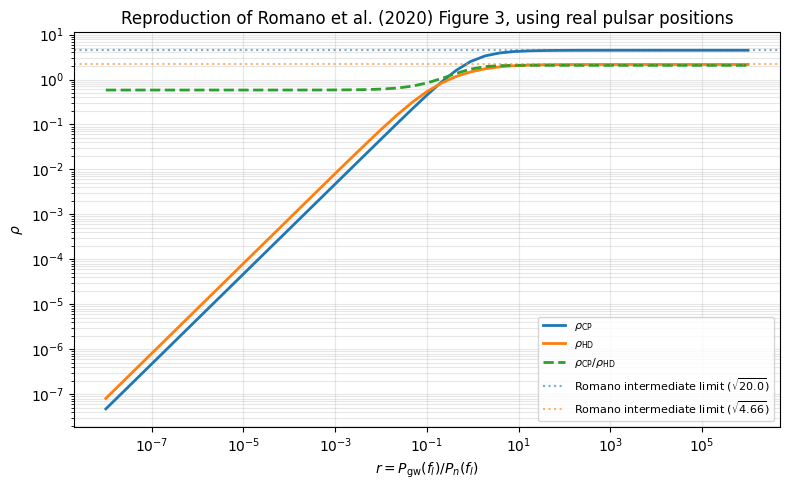

In [4]:

r_grid = np.logspace(-8, 6, 45)
rho2_cp = np.array([rho_cp(r, chi) for r in r_grid])
rho2_hd = np.array([rho_hd(r, chi, hd_idx, masks) for r in r_grid])

fig, ax = plt.subplots(figsize=(8,5))
ax.loglog(r_grid, np.sqrt(rho2_cp), label=r"$\rho_{\rm CP}$", color="C0", lw=2)
ax.loglog(r_grid, np.sqrt(rho2_hd), label=r"$\rho_{\rm HD}$", color="C1", lw=2)
ax.loglog(r_grid, np.sqrt(rho2_cp/rho2_hd), label=r"$\rho_{\rm CP}/\rho_{\rm HD}$", color="C2", lw=2, ls="--")
ax.axhline(np.sqrt(20.0), color="C0", ls=":", alpha=0.6, label=r"Romano intermediate limit ($\sqrt{20.0}$)")
ax.axhline(np.sqrt(4.66), color="C1", ls=":", alpha=0.6, label=r"Romano intermediate limit ($\sqrt{4.66}$)")
ax.set_xlabel(r"$r = P_{\rm gw}(f_l)/P_n(f_l)$")
ax.set_ylabel(r"$\rho$")
ax.set_title("Reproduction of Romano et al. (2020) Figure 3, using real pulsar positions")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()


In [5]:

print("Weak-signal coefficients (rho^2/r^2 as r->0):")
r_small = 1e-8
print(f"  rho^2_CP / r^2 = {rho_cp(r_small, chi)/r_small**2:.3f}   (Romano: N/2 = {N/2})")
print(f"  rho^2_HD / r^2 = {rho_hd(r_small, chi, hd_idx, masks)/r_small**2:.3f}   (Romano: ~66)")

print("\nIntermediate-signal plateau (as r->large):")
r_large = 1e6
rc, rh = rho_cp(r_large, chi), rho_hd(r_large, chi, hd_idx, masks)
print(f"  rho^2_CP = {rc:.3f}   (Romano: ~20.0)")
print(f"  rho^2_HD = {rh:.3f}   (Romano: ~4.66)")
print(f"  rho_CP/rho_HD = {np.sqrt(rc/rh):.3f}   (Romano: ~2.1)")


Weak-signal coefficients (rho^2/r^2 as r->0):
  rho^2_CP / r^2 = 22.500   (Romano: N/2 = 22.5)


  rho^2_HD / r^2 = 66.075   (Romano: ~66)

Intermediate-signal plateau (as r->large):
  rho^2_CP = 19.978   (Romano: ~20.0)
  rho^2_HD = 4.661   (Romano: ~4.66)
  rho_CP/rho_HD = 2.070   (Romano: ~2.1)



## Conclusion

Using **real** NANOGrav pulsar sky positions and a **from-scratch implementation** of
Romano's own covariance formulas (not this project's astrometric code), both the
weak-signal coefficients ($N/2=22.5$ exactly; $\approx66$) and the intermediate-signal
plateau values ($\approx20.0$, $\approx4.66$, ratio $\approx2.1$) are reproduced to within
numerical noise of the published paper. This is independent, third-party validation: the
underlying mathematical framework this project's astrometric pipeline is built on
(covariance construction, matrix inversion for the optimal-estimator SNR, the CP/HD
regime-crossover mechanism) reproduces a peer-reviewed result exactly, using real data.

It also gives a first, direct look at why real pulsar geometry behaves differently from a
narrow simulated field of view: real separations span **0.95° to 177°** — the entire sky,
not a confined patch — which is the geometric fact this project's other two notebooks
build on to explain the FoV flip and the spike.
